In [ ]:
# Assuming this will be run on Google Colab with CPU
from google.colab import drive
drive.mount('/content/drive')

# Please set the path according to the local environment
!ls '/content/drive/MyDrive/pitch_type_pred/'
%cd "/content/drive/MyDrive/pitch_type_pred/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset  program  results
/content/drive/MyDrive/pitch_type_pred


In [ ]:
import os
import numpy as np
import scipy.io
import glob
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
player_name="sub01" #sub01-08
temp_name="./dataset/"+player_name+"/*.mat"
mat_files = sorted(glob.glob(temp_name))

data_list = []
for f in mat_files:
    d = scipy.io.loadmat(f)
    data_list.append({"X": d["X"], "y": int(np.squeeze(d["Ball_type_binary"]))})

y_all = np.array([d["y"] for d in data_list])  # (N,)
idx_0_all = np.where(y_all == 0)[0]
idx_1_all = np.where(y_all == 1)[0]
n0_total, n1_total = len(idx_0_all), len(idx_1_all)

print(f"The total pitch number {len(data_list)}")

T = data_list[0]["X"].shape[0]
D = data_list[0]["X"].shape[1]
print("Time length:", T, " Number of input features:", D)

The total pitch number 105
Time length: 101  Number of input features: 13



=== Size per class: n=2 ===

=== Size per class: n=3 ===

=== Size per class: n=4 ===

=== Size per class: n=5 ===

=== Size per class: n=6 ===

=== Size per class: n=7 ===

=== Size per class: n=8 ===

=== Size per class: n=9 ===

=== Size per class: n=10 ===

=== Size per class: n=11 ===

=== Size per class: n=12 ===

=== Size per class: n=13 ===

=== Size per class: n=14 ===

=== Size per class: n=15 ===

=== Size per class: n=16 ===

=== Size per class: n=17 ===

=== Size per class: n=18 ===

=== Size per class: n=19 ===

=== Size per class: n=20 ===

=== Size per class: n=21 ===

=== Size per class: n=22 ===

=== Size per class: n=23 ===

=== Size per class: n=24 ===

=== Size per class: n=25 ===


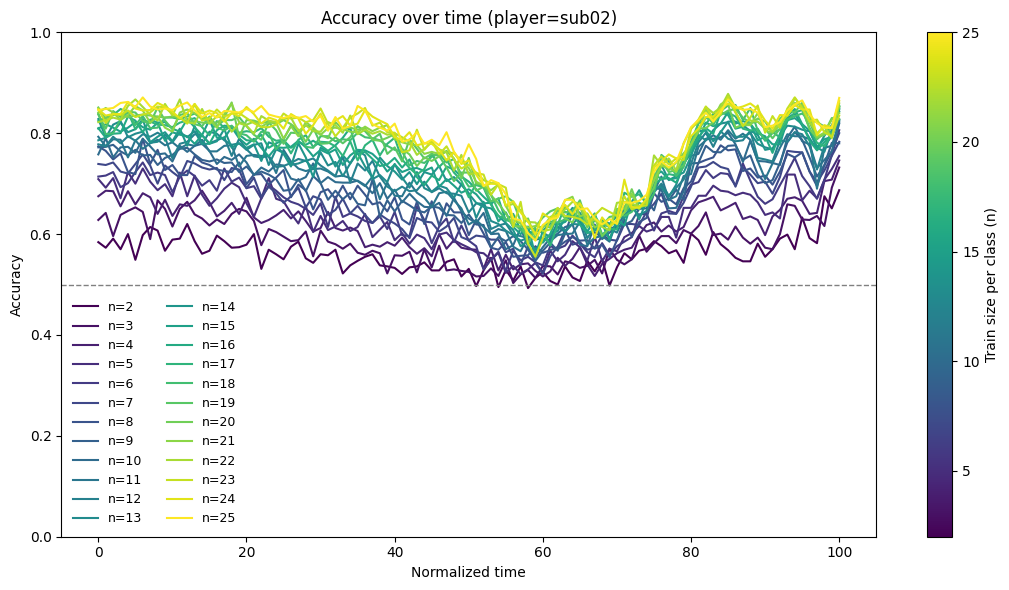

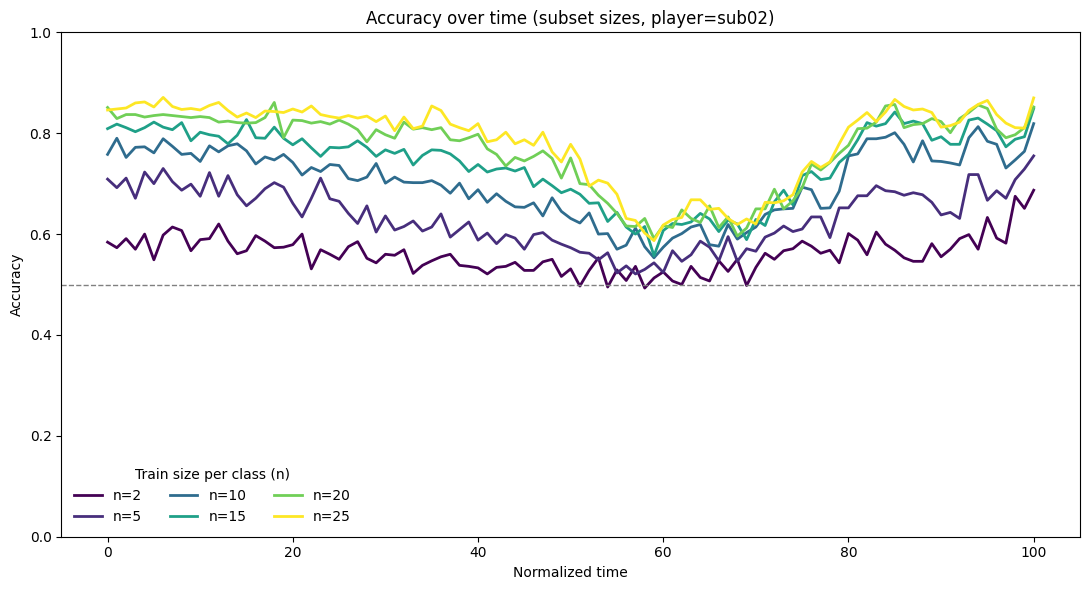

In [ ]:
np.random.seed(0)
n_repeats = 100
train_sizes = list(range(2, 26)) # from 2, 3, ..., 25
test_per_class = 5

acc_time_mean = {}     # size -> (T,)
acc_time_std  = {}     # size -> (T,)
summary_by_size = []

valid_sizes = []
# change train dataset size from 2 to 25
for n_train_class in train_sizes:
    print(f"\n=== Size per class: n={n_train_class} ===")
    acc_means = np.zeros(T) * np.nan
    acc_stds  = np.zeros(T) * np.nan

    # from time point 0 to 100
    for t in range(T):
        X_t_all = np.array([d["X"][t, :] for d in data_list])
        accs   = []

        # repeat 100 times
        for rep in range(n_repeats):
            tr1 = np.random.choice(idx_1_all, size=n_train_class, replace=False)
            rem1 = np.setdiff1d(idx_1_all, tr1)
            te1 = np.random.choice(rem1, size=test_per_class, replace=False)

            tr0 = np.random.choice(idx_0_all, size=n_train_class, replace=False)
            rem0 = np.setdiff1d(idx_0_all, tr0)
            te0 = np.random.choice(rem0, size=test_per_class, replace=False)

            train_idx = np.concatenate([tr0, tr1])
            test_idx  = np.concatenate([te0, te1])

            X_train, y_train = X_t_all[train_idx], y_all[train_idx]
            X_test,  y_test  = X_t_all[test_idx],  y_all[test_idx]

            scaler = StandardScaler()
            X_train_std = scaler.fit_transform(X_train)
            X_test_std  = scaler.transform(X_test)

            clf = LogisticRegression(max_iter=1000, solver='lbfgs', penalty='l2')
            clf.fit(X_train_std, y_train)

            accs.append(clf.score(X_test_std, y_test))

        acc_means[t] = np.mean(accs) if len(accs) else np.nan
        acc_stds[t]  = np.std(accs)  if len(accs) else np.nan

    acc_time_mean[n_train_class] = acc_means
    acc_time_std[n_train_class]  = acc_stds

    mean_acc_over_t = np.nanmean(acc_means)
    std_acc_over_t  = np.nanstd(acc_means)

    summary_by_size.append({
        "size_per_class": n_train_class,
        "mean_accuracy_all_t": mean_acc_over_t,
        "std_accuracy_all_t": std_acc_over_t
    })
    valid_sizes.append(n_train_class)

# save & visualize the results
t_range = np.arange(T)
df_acc_mean = pd.DataFrame({"t": t_range})
df_acc_std  = pd.DataFrame({"t": t_range})
for n in valid_sizes:
    df_acc_mean[f"n{n}_acc_mean"] = acc_time_mean[n]
    df_acc_std[f"n{n}_acc_std"]   = acc_time_std[n]
df_acc_mean.to_csv(f"./results/csv/accuracy_setwise_{player_name}.csv", index=False)
df_acc_std.to_csv (f"./results/csv/accuracy_setwise_{player_name}.csv",  index=False)

#Visualize the results
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=min(valid_sizes), vmax=max(valid_sizes))
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

plt.figure(figsize=(11,6))
for n in valid_sizes:
    plt.plot(t_range, acc_time_mean[n], label=f"n={n}", color=cmap(norm(n)), linewidth=1.5)
plt.ylim(0.0, 1.0)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Normalized time")
plt.ylabel("Accuracy")
plt.title(f"Accuracy over time (player={player_name})")
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Train size per class (n)")
plt.legend(ncol=2, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(f"./results/images/accuracy_setwise_{player_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()

subset_sizes = [2, 5, 10, 15, 20, 25]
subset_sizes = [n for n in subset_sizes if n in valid_sizes]

plt.figure(figsize=(11,6))
for n in subset_sizes:
    plt.plot(
        t_range,
        acc_time_mean[n],
        label=f"n={n}",
        color=cmap(norm(n)),
        linewidth=2
    )

plt.ylim(0.0, 1.0)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Normalized time")
plt.ylabel("Accuracy")
plt.title(f"Accuracy over time (subset sizes, player={player_name})")

plt.legend(ncol=3, fontsize=10, frameon=False, title="Train size per class (n)")
plt.tight_layout()
plt.savefig(f"./results/images/accuracy_setwise_subsets_{player_name}.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()